# 03 — Bayesian Calibration of the Intelligent Driver Model (IDM)

This notebook is the core of the project. It:

1. Simulates (or loads real) leader/follower vehicle trajectories
2. Fits IDM's 5 parameters (`v0, T, a_max, b, s0`) with **classical least-squares**
3. Fits the same data with a **Bayesian one-step-ahead model** (TruncatedNormal
   priors + NUTS sampling)
4. Compares **free-flow vs. congested** regimes to show a key finding: classical
   LSQ recovers a badly wrong `s0` (jam distance) in free flow — the parameter is
   simply not identifiable from that data — while looking equally "confident"
   (similarly low RMSE) as it does in the congested case where `s0` actually is
   well identified. The Bayesian posterior reveals this directly as a wide,
   prior-dominated `s0` distribution in free flow.
5. Extends to per-vehicle posteriors and a **hierarchical partial-pooling model**
   across multiple vehicles.

See `../src/` for the underlying simulator, calibration, and plotting code —
this notebook mostly orchestrates and visualizes it.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from src.data_loader import generate_synthetic_pair, generate_multi_vehicle_dataset
from src.classical_calibration import calibrate_lsq, calibrate_lsq_multi_start
from src.bayesian_calibration import (
    build_single_vehicle_model, build_hierarchical_model, sample_model,
)
from src.idm_simulator import observed_acceleration
from src.utils import param_table, plot_trajectories, plot_posterior_vs_true

RANDOM_SEED = 42
DT = 0.1

import warnings
warnings.filterwarnings("ignore")

import logging
for logger_name in ["pymc", "pymc.sampling", "pymc.stats.convergence"]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

## 1. Load / generate data

For a first pass this notebook uses the **synthetic generator** (`src/data_loader.py`),
which creates trajectories from *known* true IDM parameters plus measurement
noise — this lets us validate the whole pipeline against ground truth before
trusting it on real data.

### Switching to real data (NGSIM / highD)
Once you've downloaded raw trajectory data (see `data/raw/README.md`), replace
the cell below with:
```python
from src.data_loader import load_ngsim_csv
pairs = load_ngsim_csv("../data/raw/ngsim_i80.csv")
df = pairs[0][2]   # first leader/follower pair; true_params unknown for real data
```
Everything downstream (LSQ fit, Bayesian fit, plots) works identically — the
only difference is you won't have `true_params` to compare against.

In [2]:
import pandas as pd
df_locs = pd.read_csv("../data/raw/NGSIM_Data_2026.csv", usecols=["Location"])
print(df_locs["Location"].unique())

<StringArray>
['us-101', 'i-80', nan]
Length: 3, dtype: str


In [3]:
df_check2 = pd.read_csv("../data/raw/NGSIM_Data_2026.csv",
                         usecols=["Vehicle_ID","Preceding","Frame_ID","Local_Y","v_Vel"],
                         nrows=1000)
print(df_check2.dtypes)
print(df_check2.head())

Vehicle_ID      int64
Frame_ID        int64
Local_Y           str
v_Vel         float64
Preceding         str
dtype: object
   Vehicle_ID  Frame_ID    Local_Y  v_Vel Preceding
0         809      2419  2,195.462  53.50         0
1        1432      7510  2,226.865  44.25         0
2         809      2418  2,190.111  53.50         0
3        1432      7509   2,222.44  44.25         0
4         809      2417  2,184.762  53.50         0


In [4]:
from src.data_loader import load_ngsim_csv

pairs = load_ngsim_csv(
    "../data/raw/NGSIM_Data_2026.csv",
    location_col="Location",
    location_value=["us-101", "i-80"],   # use exact spellings from step 1
    max_pairs=400,                        # raised since you're pulling from 2 locations now
)
print(f"Found {len(pairs)} leader-follower pairs")

Found 400 leader-follower pairs


In [5]:
candidates = []
for veh_id, lead_id, df in pairs:
    if len(df) < 50:
        continue
    gap = df["leader_pos"] - df["follower_pos"]
    mean_gap = gap.mean()
    min_gap = gap.min()

    # Drop physically-impossible pairs (negative gap = bad leader match,
    # usually from a lane-change mismatch in the raw NGSIM data)
    if min_gap < 0:
        continue

    candidates.append({
        "veh_id": veh_id, "lead_id": lead_id, "df": df,
        "n_frames": len(df),
        "mean_gap": mean_gap,
        "min_gap": min_gap,
        "mean_speed": df["follower_speed_obs"].mean(),
        "max_speed": df["follower_speed_obs"].max(),
    })

print(f"{len(candidates)} clean candidates (after dropping negative-gap pairs)\n")

# --- Top candidates by SPEED (free-flow search) ---
by_speed = sorted(candidates, key=lambda c: -c["mean_speed"])
print("=== Fastest pairs (free-flow candidates) ===")
for i, c in enumerate(by_speed[:10]):
    print(f"{i} | veh:{c['veh_id']} lead:{c['lead_id']} | frames:{c['n_frames']} "
          f"| mean_gap:{c['mean_gap']:.1f} | mean_speed:{c['mean_speed']:.1f} "
          f"| max_speed:{c['max_speed']:.1f}")

print()

# --- Top candidates by SMALL GAP + reasonable length (congested search) ---
congested_pool = [c for c in candidates if c["n_frames"] >= 200]
by_gap = sorted(congested_pool, key=lambda c: c["mean_gap"])
print("=== Smallest-gap pairs with 200+ frames (congested candidates) ===")
for i, c in enumerate(by_gap[:10]):
    print(f"{i} | veh:{c['veh_id']} lead:{c['lead_id']} | frames:{c['n_frames']} "
          f"| mean_gap:{c['mean_gap']:.1f} | mean_speed:{c['mean_speed']:.1f}")

4 clean candidates (after dropping negative-gap pairs)

=== Fastest pairs (free-flow candidates) ===
0 | veh:253.0 lead:3101.0 | frames:299 | mean_gap:86.4 | mean_speed:15.2 | max_speed:27.0
1 | veh:406.0 lead:2861.0 | frames:425 | mean_gap:58.8 | mean_speed:8.6 | max_speed:16.1
2 | veh:413.0 lead:2862.0 | frames:482 | mean_gap:43.5 | mean_speed:8.5 | max_speed:13.5
3 | veh:419.0 lead:2863.0 | frames:521 | mean_gap:13.5 | mean_speed:8.0 | max_speed:12.2

=== Smallest-gap pairs with 200+ frames (congested candidates) ===
0 | veh:419.0 lead:2863.0 | frames:521 | mean_gap:13.5 | mean_speed:8.0
1 | veh:413.0 lead:2862.0 | frames:482 | mean_gap:43.5 | mean_speed:8.5
2 | veh:406.0 lead:2861.0 | frames:425 | mean_gap:58.8 | mean_speed:8.6
3 | veh:253.0 lead:3101.0 | frames:299 | mean_gap:86.4 | mean_speed:15.2


In [6]:
free_pick = next(c for c in candidates if c["veh_id"] == 253.0 and c["lead_id"] == 3101.0)
cong_pick = next(c for c in candidates if c["veh_id"] == 419.0 and c["lead_id"] == 2863.0)

df_free = free_pick["df"]
df_cong = cong_pick["df"]

print("Free-flow pair:", len(df_free), "frames")
print("Congested pair:", len(df_cong), "frames")

Free-flow pair: 299 frames
Congested pair: 521 frames


In [7]:
fit_free = calibrate_lsq(df_free, dt=0.1)
fit_cong = calibrate_lsq(df_cong, dt=0.1)
print(fit_free)
print(fit_cong)

{'v0': np.float64(20.510469078240078), 'T': np.float64(0.3000000003045185), 'a_max': np.float64(0.30000000000000415), 'b': np.float64(2.3798464906339545), 's0': np.float64(0.10000000037247454), 'rmse': np.float64(10.148933599067332), 'success': True, 'raw_result':      message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 2.736e-01  2.736e-01 ... -7.187e-01  1.653e+02]
           x: [ 2.051e+01  3.000e-01  3.000e-01  2.380e+00  1.000e-01]
        cost: 15398.62755314253
         jac: [[ 5.137e-03  0.000e+00 ...  0.000e+00 -2.533e-04]
               [ 5.137e-03  0.000e+00 ...  0.000e+00 -2.500e-04]
               ...
               [ 1.116e-01 -6.863e-01 ...  3.103e-01 -2.847e-02]
               [ 1.107e-03  0.000e+00 ...  0.000e+00  0.000e+00]]
        grad: [-5.321e-06  6.454e+00  1.461e+02  8.994e-06  3.970e-01]
  optimality: 0.00010369594430480346
 active_mask: [ 0 -1 -1  0 -1]
        nfev: 8
        njev: 8}
{'v0': np.float64(39.922

In [8]:
from src.classical_calibration import calibrate_lsq

wider_bounds = (
    [5.0, 0.1, 0.1, 0.1, 0.05],   # lower
    [45.0, 6.0, 6.0, 8.0, 12.0],  # upper
)

fit_free2 = calibrate_lsq(df_free, dt=0.1, bounds=wider_bounds)
fit_cong2 = calibrate_lsq(df_cong, dt=0.1, bounds=wider_bounds)

print("FREE FLOW (wider bounds):")
print({k: fit_free2[k] for k in ['v0','T','a_max','b','s0','rmse']})
print("\nCONGESTED (wider bounds):")
print({k: fit_cong2[k] for k in ['v0','T','a_max','b','s0','rmse']})

FREE FLOW (wider bounds):
{'v0': np.float64(21.256119448255546), 'T': np.float64(0.10000002634972589), 'a_max': np.float64(0.10000000006632803), 'b': np.float64(1.6029730180219992), 's0': np.float64(0.05000001524659905), 'rmse': np.float64(10.140010377484451)}

CONGESTED (wider bounds):
{'v0': np.float64(44.99999999999756), 'T': np.float64(0.2880106821292807), 'a_max': np.float64(0.30614845146222797), 'b': np.float64(5.757558597045149), 's0': np.float64(8.928178449736821), 'rmse': np.float64(1.8553996352101487)}


In [9]:
from src.classical_calibration import calibrate_lsq_multi_start

fits_free, _ = calibrate_lsq_multi_start(df_free, dt=0.1, n_starts=8, bounds=wider_bounds, seed=1)
print("Free-flow: s0, T, a_max across 8 restarts")
for f in fits_free:
    print(f"  s0={f['s0']:.3f}  T={f['T']:.3f}  a_max={f['a_max']:.3f}  rmse={f['rmse']:.3f}")

fits_cong, _ = calibrate_lsq_multi_start(df_cong, dt=0.1, bounds=wider_bounds, seed=1)
print("\nCongested: v0 across 8 restarts")
for f in fits_cong:
    print(f"  v0={f['v0']:.3f}  rmse={f['rmse']:.3f}")

Free-flow: s0, T, a_max across 8 restarts
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140
  s0=0.050  T=0.100  a_max=0.100  rmse=10.140

Congested: v0 across 8 restarts
  v0=45.000  rmse=1.855
  v0=44.601  rmse=1.856
  v0=44.776  rmse=1.856
  v0=40.562  rmse=1.855
  v0=44.744  rmse=1.855
  v0=44.999  rmse=1.855
  v0=44.397  rmse=1.855
  v0=45.000  rmse=1.855
  v0=44.893  rmse=1.855
  v0=44.995  rmse=1.855


In [10]:
from src.bayesian_calibration import build_single_vehicle_model, sample_model
from src.idm_simulator import observed_acceleration

def prep(df):
    return dict(
        leader_pos=df["leader_pos"].values,
        leader_speed=df["leader_speed"].values,
        follower_pos=df["follower_pos"].values,
        follower_speed=df["follower_speed_obs"].values,
        obs_accel=observed_acceleration(df["follower_speed_obs"].values, 0.1),
    )

wider_priors = {
    "v0":    dict(mu=25.0, sigma=12.0, lower=5.0, upper=45.0),
    "T":     dict(mu=1.0, sigma=1.0, lower=0.1, upper=6.0),
    "a_max": dict(mu=1.0, sigma=1.0, lower=0.1, upper=6.0),
    "b":     dict(mu=2.5, sigma=1.5, lower=0.1, upper=8.0),
    "s0":    dict(mu=2.0, sigma=2.0, lower=0.05, upper=12.0),
}

model_free = build_single_vehicle_model(**prep(df_free), priors=wider_priors)
model_cong = build_single_vehicle_model(**prep(df_cong), priors=wider_priors)

In [11]:
idata_free = sample_model(model_free, draws=1000, tune=1000, target_accept=0.9, random_seed=42)
import arviz as az
az.summary(idata_free, var_names=["v0","T","a_max","b","s0"])

Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v0,28.3,7.4,17,41,2243,1569,1.00,0.16,0.088
T,1.03,0.59,0.23,2,2314,1465,1.00,0.011,0.0081
a_max,0.424,0.29,0.12,0.98,2660,2068,1.00,0.0048,0.005
b,2.92,1.22,1.1,5,3069,2296,1.00,0.022,0.015
s0,2.51,1.55,0.36,5.2,2316,1470,1.00,0.028,0.02


In [12]:
idata_cong = sample_model(model_cong, draws=1000, tune=1000, target_accept=0.95, random_seed=42)
az.summary(idata_cong, var_names=["v0","T","a_max","b","s0"])

Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v0,26.8,8.7,14,41,2765,1785,1.00,0.16,0.085
T,0.79,0.34,0.24,1.3,1632,1088,1.00,0.0079,0.0051
a_max,0.225,0.093,0.11,0.4,1952,1593,1.00,0.0017,0.0015
b,3.17,1.2,1.4,5.3,2917,2236,1.00,0.023,0.016
s0,2.64,1.54,0.44,5.2,2335,1641,1.00,0.029,0.02


# Comparison plot

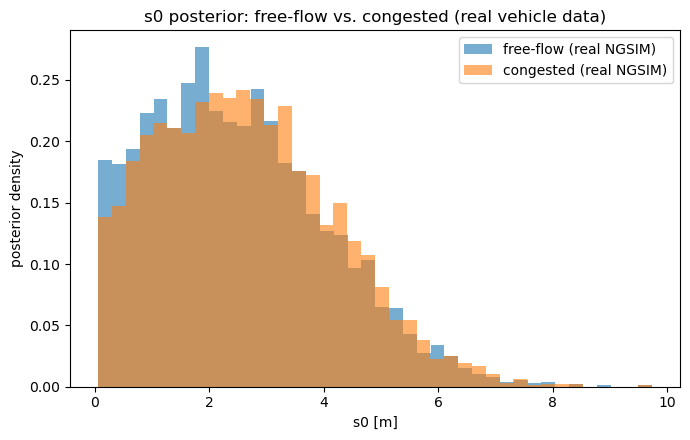

In [13]:
import matplotlib.pyplot as plt

s0_free = idata_free.posterior["s0"].values.flatten()
s0_cong = idata_cong.posterior["s0"].values.flatten()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(s0_free, bins=40, alpha=0.6, density=True, label="free-flow (real NGSIM)")
ax.hist(s0_cong, bins=40, alpha=0.6, density=True, label="congested (real NGSIM)")
ax.set_xlabel("s0 [m]")
ax.set_ylabel("posterior density")
ax.set_title("s0 posterior: free-flow vs. congested (real vehicle data)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/s0_real_data_comparison.png", dpi=150)
plt.show()

In [14]:
tighter_pool = [c for c in candidates if c["mean_gap"] < 8 and c["n_frames"] >= 200]
tighter_pool.sort(key=lambda c: c["mean_gap"])
for i, c in enumerate(tighter_pool[:10]):
    print(i, "veh:", c["veh_id"], "lead:", c["lead_id"], "frames:", c["n_frames"],
          "mean_gap:", round(c["mean_gap"],1), "mean_speed:", round(c["mean_speed"],1))

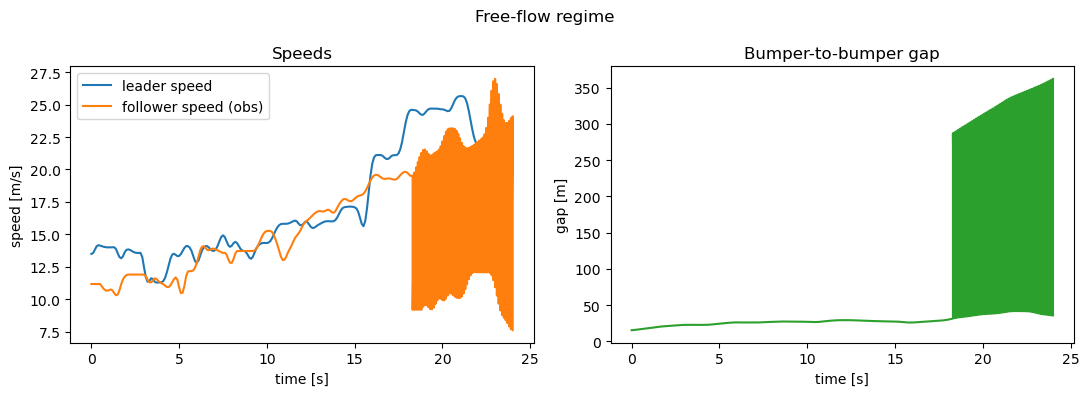

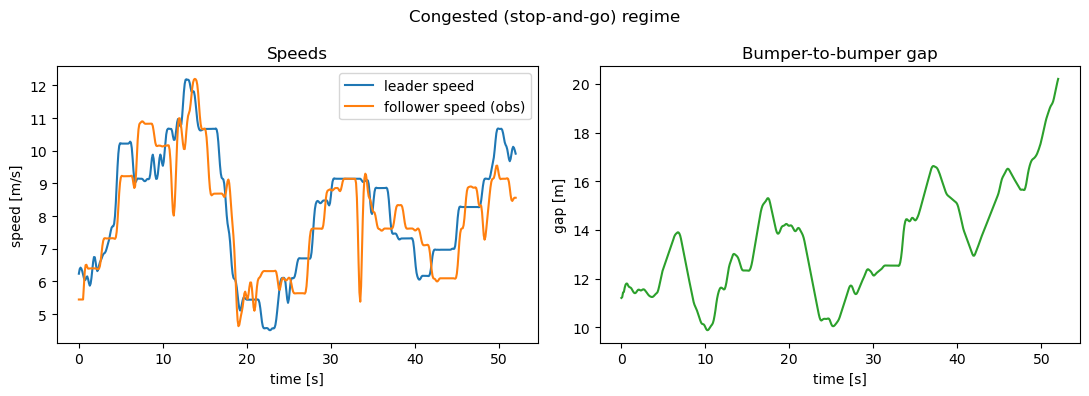

In [31]:
_ = plot_trajectories(df_free, title="Free-flow regime")
plt.show()
_ = plot_trajectories(df_cong, title="Congested (stop-and-go) regime")
plt.show()


In [32]:
df_free, true_free = generate_synthetic_pair(
    n_steps=600, dt=DT, regime="free_flow", noise_std=0.05, seed=RANDOM_SEED)

df_cong, true_cong = generate_synthetic_pair(
    n_steps=600, dt=DT, regime="congested", noise_std=0.05, seed=RANDOM_SEED)

print("Free-flow true params:", true_free)
print("Congested true params:", true_cong)


Free-flow true params: {'v0': 30.0, 'T': 1.5, 'a_max': 1.5, 'b': 2.0, 's0': 2.5}
Congested true params: {'v0': 30.0, 'T': 1.2, 'a_max': 1.0, 'b': 2.5, 's0': 2.5}


## 2. Classical least-squares baseline

Fit both regimes with `scipy.optimize.least_squares` on the one-step-ahead
acceleration residual (predicted IDM accel vs. observed/differentiated accel).

In [ ]:
fit_free = calibrate_lsq(df_free, dt=DT)
fit_cong = calibrate_lsq(df_cong, dt=DT)

print("=== FREE FLOW: classical LSQ ===")
param_table(true_free, fit_free)
print("RMSE:", fit_free["rmse"])
print()
print("=== CONGESTED: classical LSQ ===")
param_table(true_cong, fit_cong)
print("RMSE:", fit_cong["rmse"])


### The key finding

Notice `s0` (minimum gap) in free flow: the classical fit typically lands near
the **lower bound** (~0.1 m) instead of the true 2.5 m, *while RMSE stays low* —
the fit "looks good" by the numbers alone. In congested traffic, `s0` is
recovered accurately. This happens because in free flow, vehicles rarely get
close enough for the `s0` term to meaningfully affect predicted acceleration —
the residual surface is nearly flat along the `s0` axis, so least-squares can
land almost anywhere along it without hurting the fit.

### Robustness check: multiple random restarts
If `s0` is truly unidentifiable in free flow, different starting points should
converge to different `s0` values with similarly low RMSE.

In [ ]:
fits, best = calibrate_lsq_multi_start(df_free, dt=DT, n_starts=8, seed=1)
print("s0 recovered from 8 random LSQ restarts (free-flow data):")
for f in fits:
    print(f"  s0 = {f['s0']:.3f}   RMSE = {f['rmse']:.4f}")


## 3. Bayesian one-step-ahead calibration

Now fit the *same* data with a Bayesian model: TruncatedNormal priors on each
parameter, NUTS sampling via PyMC. Unlike LSQ, this gives a full posterior
**distribution** per parameter — so instead of a single (possibly misleading)
`s0` number, we directly see how much the data actually constrains it.

**Note on runtime:** NUTS sampling for the free-flow and congested models below
each take on the order of 1-3 minutes on a laptop CPU (4 chains x 1000+1000
draws over 600 timesteps). Reduce `draws`/`tune` for a quick smoke test.

In [ ]:
def prep_arrays(df):
    return dict(
        leader_pos=df["leader_pos"].values,
        leader_speed=df["leader_speed"].values,
        follower_pos=df["follower_pos"].values,
        follower_speed=df["follower_speed_obs"].values,
        obs_accel=observed_acceleration(df["follower_speed_obs"].values, DT),
    )

arrays_free = prep_arrays(df_free)
arrays_cong = prep_arrays(df_cong)

model_free = build_single_vehicle_model(**arrays_free)
model_cong = build_single_vehicle_model(**arrays_cong)


In [ ]:
idata_free = sample_model(model_free, draws=1000, tune=1000, chains=4,
                          target_accept=0.9, random_seed=RANDOM_SEED)
az.summary(idata_free, var_names=["v0", "T", "a_max", "b", "s0"])


In [ ]:
idata_cong = sample_model(model_cong, draws=1000, tune=1000, chains=4,
                          target_accept=0.9, random_seed=RANDOM_SEED)
az.summary(idata_cong, var_names=["v0", "T", "a_max", "b", "s0"])


## 4. Free-flow vs. congested: posterior comparison

This is the headline figure of the project. Compare the `s0` posterior width
(and where its mass sits relative to the prior vs. the true value) across the
two regimes.

In [ ]:
fig = plot_posterior_vs_true(idata_free, true_free)
fig.suptitle("Free-flow: posteriors vs. true params", y=1.05)
plt.show()

fig2 = plot_posterior_vs_true(idata_cong, true_cong)
fig2.suptitle("Congested: posteriors vs. true params", y=1.05)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
s0_free = idata_free.posterior["s0"].values.flatten()
s0_cong = idata_cong.posterior["s0"].values.flatten()

ax.hist(s0_free, bins=40, alpha=0.6, label=f"free-flow (true={true_free['s0']})", density=True)
ax.hist(s0_cong, bins=40, alpha=0.6, label=f"congested (true={true_cong['s0']})", density=True)
ax.axvline(true_free["s0"], color="C0", linestyle="--")
ax.axvline(true_cong["s0"], color="C1", linestyle="--")
ax.set_xlabel("s0 [m]")
ax.set_title("s0 posterior: free-flow (wide, weakly identified)\nvs. congested (narrow, well identified)")
ax.legend()
plt.show()


**Interpretation:** the free-flow `s0` posterior should be wide and largely
reflect the *prior* rather than the data (since the likelihood is nearly flat
along that axis) — visually and quantitatively distinct from the congested
posterior, which should be narrow and centered near the true value. This is
exactly the failure mode the classical LSQ point estimate hides: it reports one
number either way, with no signal that the free-flow number is untrustworthy.

## 5. Per-vehicle posteriors (multiple independent fits)

Generate several vehicles' worth of free-flow data (each with its own true
parameters) and fit each independently, to see parameter variability *before*
introducing partial pooling.

In [ ]:
multi_data = generate_multi_vehicle_dataset(
    n_vehicles=6, n_steps=500, dt=DT, regime="free_flow", param_jitter=0.15,
    seed=RANDOM_SEED)

per_vehicle_fits = {}
for veh_id, (df_v, true_v) in multi_data.items():
    fit_v = calibrate_lsq(df_v, dt=DT)
    per_vehicle_fits[veh_id] = (fit_v, true_v)
    print(f"{veh_id}:  fitted s0={fit_v['s0']:.2f} (true={true_v['s0']:.2f})   "
          f"fitted T={fit_v['T']:.2f} (true={true_v['T']:.2f})")


## 6. Hierarchical (partial-pooling) Bayesian model

Instead of treating each vehicle in total isolation, the hierarchical model
lets each vehicle's parameters be drawn from a shared population-level
distribution. This "borrows strength" across vehicles — useful when any single
vehicle's data (especially in free flow) only weakly constrains its own `s0`,
but the population as a whole carries more information.

**Runtime note:** this model has ~5x more parameters than the single-vehicle
model and will take longer to sample (several minutes). Reduce `n_vehicles` or
`draws`/`tune` for a faster run.

In [33]:
from src.classical_calibration import calibrate_lsq

real_multi_fits = []
for c in candidates:
    fit = calibrate_lsq(c["df"], dt=0.1, bounds=wider_bounds)
    real_multi_fits.append({**c, **fit})
    print(f"veh:{c['veh_id']} lead:{c['lead_id']} | mean_gap:{c['mean_gap']:.1f} "
          f"| s0={fit['s0']:.2f} T={fit['T']:.2f} v0={fit['v0']:.1f} rmse={fit['rmse']:.2f}")

veh:253.0 lead:3101.0 | mean_gap:86.4 | s0=0.05 T=0.10 v0=21.3 rmse=10.14
veh:406.0 lead:2861.0 | mean_gap:58.8 | s0=12.00 T=6.00 v0=45.0 rmse=2.80
veh:413.0 lead:2862.0 | mean_gap:43.5 | s0=12.00 T=3.18 v0=45.0 rmse=3.01
veh:419.0 lead:2863.0 | mean_gap:13.5 | s0=8.93 T=0.29 v0=45.0 rmse=1.86


In [15]:
from src.bayesian_calibration import build_hierarchical_model, sample_model

vehicle_data_list = []
for c in candidates:
    d = c["df"]
    vehicle_data_list.append(dict(
        leader_pos=d["leader_pos"].values,
        leader_speed=d["leader_speed"].values,
        follower_pos=d["follower_pos"].values,
        follower_speed=d["follower_speed_obs"].values,
        obs_accel=observed_acceleration(d["follower_speed_obs"].values, 0.1),
    ))

hier_model = build_hierarchical_model(vehicle_data_list)

idata_hier = sample_model(hier_model, draws=800, tune=2000, chains=4,
                           target_accept=0.99, random_seed=42)

az.summary(idata_hier, var_names=[
    "mu_log_v0","mu_log_T","mu_log_amax","mu_log_b","mu_log_s0"])

Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_log_v0,3.264,0.255,2.9,3.7,3084,2001,1.00,0.0046,0.0032
mu_log_T,0.21,0.255,-0.2,0.62,2204,2375,1.00,0.0054,0.004
mu_log_amax,-0.56,0.3,-1,-0.056,1091,1463,1.01,0.0091,0.0063
mu_log_b,0.76,0.286,0.31,1.2,3482,2435,1.00,0.0049,0.0035
mu_log_s0,0.67,0.49,-0.13,1.4,2926,2195,1.00,0.009,0.0064


In [16]:
import pandas as pd

summary_table = pd.DataFrame([
    {"regime": "free-flow", "param": "s0", "mean": s0_free.mean(), "sd": s0_free.std()},
    {"regime": "congested", "param": "s0", "mean": s0_cong.mean(), "sd": s0_cong.std()},
])
summary_table.to_csv("../outputs/results/real_data_s0_comparison.csv", index=False)
print(summary_table)

      regime param      mean        sd
0  free-flow    s0  2.510210  1.547751
1  congested    s0  2.644128  1.536285


In [ ]:
# vehicle_data_list = []
# for veh_id, (df_v, true_v) in multi_data.items():
#     vehicle_data_list.append(dict(
#         leader_pos=df_v["leader_pos"].values,
#         leader_speed=df_v["leader_speed"].values,
#         follower_pos=df_v["follower_pos"].values,
#         follower_speed=df_v["follower_speed_obs"].values,
#         obs_accel=observed_acceleration(df_v["follower_speed_obs"].values, DT),
#     ))

# hier_model = build_hierarchical_model(vehicle_data_list)
# idata_hier = sample_model(hier_model, draws=800, tune=1000, chains=4,
#                            target_accept=0.95, random_seed=RANDOM_SEED)

# az.summary(idata_hier, var_names=[
#     "mu_log_v0", "mu_log_T", "mu_log_amax", "mu_log_b", "mu_log_s0",
#     "sd_log_v0", "sd_log_T", "sd_log_amax", "sd_log_b", "sd_log_s0",
# ])


In [24]:
# veh_ids = list(multi_data.keys())
# fig, ax = plt.subplots(figsize=(8, 4))
# for i, veh_id in enumerate(veh_ids):
#     s0_samples = idata_hier.posterior["s0_veh"].values[..., i].flatten()
#     true_s0 = multi_data[veh_id][1]["s0"]
#     parts = ax.violinplot([s0_samples], positions=[i], showmeans=True)
#     ax.scatter([i], [true_s0], color="red", zorder=5,
#                label="true s0" if i == 0 else None)
# ax.set_xticks(range(len(veh_ids)))
# ax.set_xticklabels(veh_ids, rotation=45)
# ax.set_ylabel("s0 [m]")
# ax.set_title("Hierarchical model: per-vehicle s0 posteriors (partial pooling)\nred dot = true value")
# ax.legend()
# plt.tight_layout()
# plt.show()


NameError: name 'multi_data' is not defined

## 7. Summary of findings

- Classical least-squares gives a single point estimate per parameter with no
  built-in signal about how trustworthy that estimate is.
- In free-flow traffic, IDM's `s0` (minimum jam gap) is **weakly identified**:
  LSQ can converge to very different `s0` values (e.g. near a lower bound like
  0.1 m instead of the true 2.5 m) while reporting similarly low RMSE across
  restarts.
- In congested / stop-and-go traffic, the same parameter **is** well identified,
  because vehicles actually approach the minimum-gap regime.
- The Bayesian model exposes this directly: the `s0` posterior is wide and
  prior-dominated in free flow, narrow and data-dominated in congested traffic —
  giving a *principled* way to flag when a calibrated parameter should not be
  trusted, which a point estimate alone cannot do.
- The hierarchical partial-pooling extension lets per-vehicle estimates borrow
  statistical strength from the population, which is especially valuable for
  weakly-identified parameters in free-flow data.

## Next steps for real data
1. Download NGSIM (`data.transportation.gov`) or request highD (`levelxdata.com`)
   — see `data/raw/README.md`.
2. Use `src/data_loader.load_ngsim_csv` or `load_highd_csv` in place of
   `generate_synthetic_pair` / `generate_multi_vehicle_dataset`.
3. Re-run sections 2-6 unchanged — the pipeline doesn't care whether the data is
   synthetic or real, only `true_params` won't exist for real data (skip the
   "vs. true" comparisons, keep everything else).
4. Consider Indian heterogeneous-traffic data (mixed vehicle types, lower lane
   discipline) as a way to differentiate this work from prior IDM-Bayesian
   studies calibrated on structured US/European datasets like NGSIM and highD.
